In [38]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as mattyp

In [39]:
daily_data = pd.read_csv('../data/citibike_weather_daily_clean.csv')
daily_data['ride_date'] = pd.to_datetime(daily_data['ride_date'])
daily_data.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,days_since_launch,temp_f_squared,is_weekend
0,2013-07-01,16650,16.31,74.8,78.1,73.4,7.8,0.00,Monday,7,True,False,False,False,False,False,0,5595.04,0
1,2013-07-02,22745,15.97,76.1,82.9,73.0,8.0,0.73,Tuesday,7,False,False,False,False,True,False,1,5791.21,0
2,2013-07-03,21864,16.24,78.5,84.9,73.9,8.8,0.06,Wednesday,7,False,False,False,False,False,True,2,6162.25,0
3,2013-07-04,22326,21.22,82.0,91.0,73.9,8.6,0.96,Thursday,7,False,False,False,True,False,False,3,6724.00,0
4,2013-07-05,21842,18.04,84.4,93.0,75.9,9.0,0.00,Friday,7,False,False,False,False,False,False,4,7123.36,0


In [40]:
target = 'num_rides'
drop_cols = ['ride_date', 'day_of_week', 'num_rides']

x = daily_data.drop(columns=drop_cols)
y = daily_data[target]

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)

(1288, 16) (322, 16)


In [42]:
core_features = [
    'temp_f', 'precip_in', 'wind_speed_knots',
    'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday',
    'days_since_launch'
]

x_train_core = x_train[core_features]
x_test_core = x_test[core_features]

In [43]:
model = LinearRegression()
model.fit(x_train_core, y_train)

LinearRegression()

In [44]:
print(model.intercept_)
print(pd.Series(model.coef_, index=core_features))

-8282.96063343811
temp_f                566.650040
precip_in           -3874.420703
wind_speed_knots     -371.197523
day_Monday           -869.810162
day_Saturday        -5649.694412
day_Sunday          -7291.441064
day_Thursday         1078.470587
day_Tuesday           685.998976
day_Wednesday        1429.930860
days_since_launch      16.406223
dtype: float64


## M4: Interpret the Coefficients
Temperature and precipitation are the strongest drivers; each degree fahrenheit adds about 567 rides, while an inch of rain costs nearly 3,874 rides. Rain matters far more than wind (−371/knots). Also weekends see a big drop versus Friday (Saturday −5,650, Sunday −7,291) and ridership has also grown modestly over time (+16 rides per day).

Comparing these signs to our EDA: most match. The weekend drop lines up with our EDA finding that ridership dips on Saturday and Sunday. Rides increasing daily (+16/day) also matches the "ridership increasing year over year" pattern we saw earlier in the EDA.

One coefficient does stand out, **temperature**. The scatter plots from E3 showed ridership isn't linear with temperature, it climbs then falls off sharply past a certain point, and a linear model can only bend into that curve if it has a squared version of the feature to work with. This happens here, our linear model can only fit one constant slope (+567 rides/°F) across the entire range, so it assumes ridership keeps climbing indefinitely as temperature rises. This means the model likely overpredicts rides on the hottest days; our stretch feature temp_f_squared is meant to help remedy this.



In [45]:
train_preds = model.predict(x_train_core)
test_preds = model.predict(x_test_core)

r2_train = r2_score(y_train, train_preds)
r2_test = r2_score(y_test, test_preds)

mae_test = mean_absolute_error(y_test, test_preds)
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))

print(f"Train R²: {r2_train:.3f}")
print(f"Test R²: {r2_test:.3f}")
print(f"Test MAE: {mae_test:.1f} rides")
print(f"Test RMSE: {rmse_test:.1f} rides")

Train R²: 0.732
Test R²: 0.744
Test MAE: 6948.6 rides
Test RMSE: 8773.5 rides


## Model Performance

Train R² is 0.732 and test R² is 0.744. **Test R² means our model explains about 74.4% of the day to day variation in ride counts on days it has never seen before**, a solid amount, though a meaningful amount of variation (~26%) is still unexplained by temperature, precipitation, wind, day of week, and the time trend alone. We care about the test number over the training number because training R² only reflects how well the model fits data it has already memorized, while test R² is the honest measure of how the model performs on new days.

Test MAE is 6,948.6 rides and test RMSE is 8,773.5 rides. **Our prediction is typically off by about 6,950 rides on a given day**. RMSE is considerably larger than MAE (8,773.5 vs 6,948.6). This tells us the total error isn't spread evenly across all test days; a handful of badly missed days are pulling RMSE up disproportionately. I suspect these off days are extreme weather events or holidays not fully captured by our features (a major storm such as a hurricane or holidays such as christmas, new years, July 4th etc. )

In [46]:
residuals = y_test - test_preds
worst_days = pd.DataFrame({
    'ride_date': daily_data.loc[y_test.index, 'ride_date'],
    'actual': y_test,
    'predicted': test_preds,
    'residual': residuals
}).sort_values('residual', key=abs, ascending=False)

worst_days.head(10)

,ride_date,actual,predicted,residual
1395,2017-10-29,9537,42418.663243,-32881.663243
907,2015-12-25,12333,39873.982751,-27540.982751
1323,2017-08-18,36620,57379.113193,-20759.113193
1168,2016-09-15,67331,46658.896263,20672.103737
1288,2017-07-14,31851,52295.181812,-20444.181812
1579,2018-05-01,72035,52633.679084,19401.320916
1343,2017-09-07,69519,50153.853349,19365.146651
1189,2017-04-06,18020,36850.990299,-18830.990299
1399,2017-11-02,70810,52011.302898,18798.697102
983,2016-03-14,10930,29480.854756,-18550.854756


## Investigating the Worst Misses

The single worst miss was **October 29, 2017**, which had a bomb cyclone nor'easter that brought hurricane like winds and heavy rain to the Northeast. The model predicted about 42,400 rides, but actual ridership was only 9,537. The second largest miss was **December 25, 2015**, the warmest Christmas on record in NYC (66°F); the model predicted about 39,900 rides based on the warm weather, but actual ridership was only 12,333.

Both cases show the same limitation; our features (temperature, precipitation, wind, day of week, trend) can't distinguish a *normal* rainy or warm day from a *dangerous storm* or a *holiday*, both of which have an extreme effect on normal ridership.

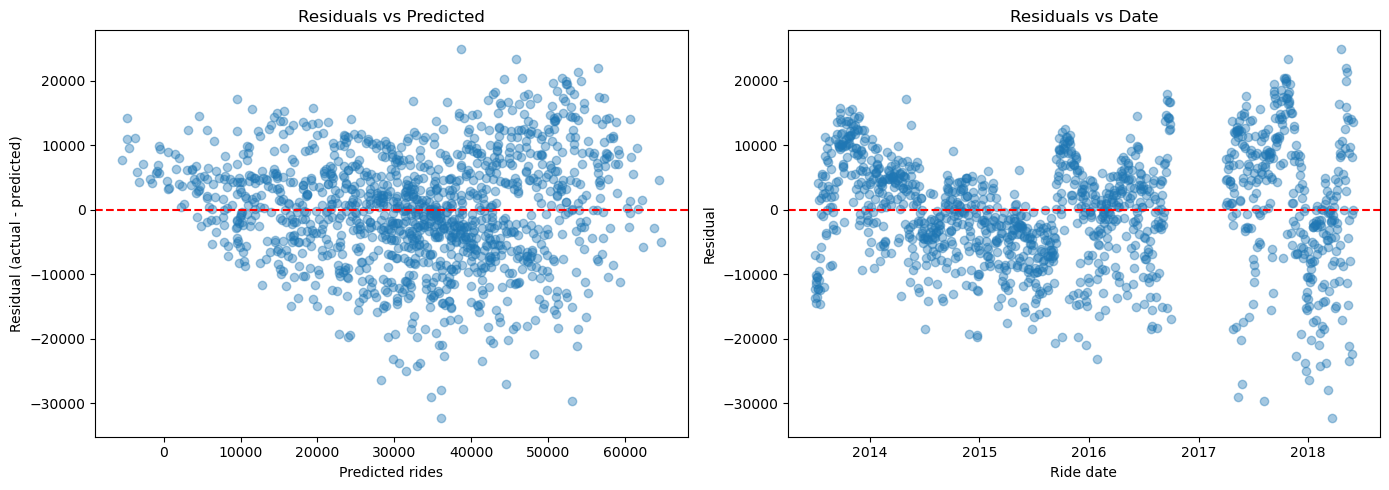

In [47]:
residuals_train = y_train - model.predict(x_train_core)

fig, axes = mattyp.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(model.predict(x_train_core), residuals_train, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted rides')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(daily_data.loc[y_train.index, 'ride_date'], residuals_train, alpha=0.4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Ride date')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Date')

mattyp.tight_layout()
mattyp.savefig('../Visualizations/05residuals')
mattyp.show()
mattyp.close()

## M5: Residual Diagnosis

Residuals vs predicted spreads out a lot, the range gets a lot wider as predicted rides go up. There's also a bit of a curve, residuals climb then bend back down at the highest predicted values, meaning the model is overpredicting on the days it expects high ridership. This matches what I saw in EDA, ridership doesn't keep climbing with temperature forever, it falls off past a certain point and a straight line can't bend to match that.

Residuals vs date is a repeating wave, up and down which probably represents seasonal patterns. There's no real long term drift, so the trend feature seems to be doing its job. There's also a gap around 2017 which lines up with the missing data period from earlier.

In [48]:
core_features_v2 = core_features + ['temp_f_squared']

x_train_v2 = daily_data.loc[x_train.index, core_features_v2]
x_test_v2 = daily_data.loc[x_test.index, core_features_v2]

model_v2 = LinearRegression()
model_v2.fit(x_train_v2, y_train)

test_preds_v2 = model_v2.predict(x_test_v2)
r2_test_v2 = r2_score(y_test, test_preds_v2)

print(f"Test R² before (core features): {r2_test:.3f}")
print(f"Test R² after (+ temp_f_squared): {r2_test_v2:.3f}")

Test R² before (core features): 0.744
Test R² after (+ temp_f_squared): 0.752


## M6: Adding temp_f_squared

Based on the curve in the residuals vs predicted plot, I added temp_f_squared to let the model bend at high temperatures instead of assuming a constant slope. Test R² went from 0.744 to 0.752 after adding it. Adding temp_f_squared improved the model slightly and it accounts for 75 % of the day to day variance in rides overall a solid model overall, though still missing the holiday and extreme weather effects we found earlier.